<a href="https://colab.research.google.com/github/rohannfr/Data-Analysis-Olist-Problem/blob/main/notebook/Olist_Marketplace_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Olist Marketplace Performance & Customer Satisfaction Analysis

**Analysts:** Rohan (Data Architect) & Gaurav (Business Strategist)
**Dataset:** Brazilian E-Commerce Public Dataset by Olist (Kaggle, CC BY-NC-SA) — ~99,441 orders, Sep 2016 - Oct 2018
**Companion report:** `Olist_Marketplace_Analysis.md` (this notebook reproduces every number and chart in that report, runnable end-to-end)

## Contents
1. Setup & Data Loading
2. Data Quality & Cleaning
3. Building the Master Order-Level Dataset
4. Q1 — Marketplace Performance Over Time
5. Q2 — Delivery Performance & Customer Satisfaction
6. Q3 — Seller & Geographic Patterns
7. Q4 — Product Category Performance
8. Q5 — Payment Behavior
9. Q6 — Root Cause Analysis (Random Forest)
10. Bonus — Repeat Customer Economics
11. Summary of Findings


## 1. Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)

# --- Data location -----------------------------------------------------------
# Shared dataset folder: https://drive.google.com/drive/folders/1EQEEg3VDVGtP2WqxcvXRDGjH-IG4ex2t
#
# * Google Colab: open the link above and click "Add shortcut to Drive" so the
#   "Olist_Data" folder appears in your own My Drive. This cell mounts your
#   Drive automatically and reads the CSVs straight from there.
# * Local Jupyter: download the 9 CSVs from the link above into a folder named
#   "Olist_Data" placed next to this notebook (or point BASE at wherever you
#   saved them).
import os

BASE = None
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/Olist_Data/'
except ImportError:
    for candidate in ('./Olist_Data/', './data/', './'):
        if os.path.isfile(candidate + 'olist_orders_dataset.csv'):
            BASE = candidate
            break
    BASE = BASE or './Olist_Data/'

if not os.path.isfile(BASE + 'olist_orders_dataset.csv'):
    raise FileNotFoundError(
        f"Couldn't find the Olist CSVs under '{BASE}'.\n"
        "Grab the data from the shared Drive folder first:\n"
        "https://drive.google.com/drive/folders/1EQEEg3VDVGtP2WqxcvXRDGjH-IG4ex2t\n"
        "- On Colab: open that link, click 'Add shortcut to Drive', then re-run this cell.\n"
        "- Locally: download the 9 CSVs into an 'Olist_Data' folder next to this notebook,\n"
        "  or edit BASE above to point at wherever you saved them."
    )

customers = pd.read_csv(BASE+'olist_customers_dataset.csv')
geo       = pd.read_csv(BASE+'olist_geolocation_dataset.csv')
items     = pd.read_csv(BASE+'olist_order_items_dataset.csv')
payments  = pd.read_csv(BASE+'olist_order_payments_dataset.csv')
reviews   = pd.read_csv(BASE+'olist_order_reviews_dataset.csv')
orders    = pd.read_csv(BASE+'olist_orders_dataset.csv')
products  = pd.read_csv(BASE+'olist_products_dataset.csv')
sellers   = pd.read_csv(BASE+'olist_sellers_dataset.csv')
cat_trans = pd.read_csv(BASE+'product_category_name_translation.csv')

for name, df in [('customers',customers),('geo',geo),('items',items),('payments',payments),
                  ('reviews',reviews),('orders',orders),('products',products),
                  ('sellers',sellers),('cat_trans',cat_trans)]:
    print(f"{name:12s}: {df.shape}")


Mounted at /content/drive
customers   : (99441, 5)
geo         : (1000163, 5)
items       : (112650, 7)
payments    : (103886, 5)
reviews     : (99224, 7)
orders      : (99441, 8)
products    : (32951, 9)
sellers     : (3095, 4)
cat_trans   : (71, 2)


## 2. Data Quality & Cleaning

**[Rohan]:** Before trusting any chart, run a full integrity pass: nulls, duplicates, outliers, and status breakdowns.

In [ ]:
print("=== NULLS (columns with at least one) ===")
for name, df in [('customers',customers),('items',items),('payments',payments),
                  ('reviews',reviews),('orders',orders),('products',products),('sellers',sellers)]:
    n = df.isnull().sum()
    n = n[n>0]
    if len(n):
        print(f"\n{name}:")
        print(n)


=== NULLS (columns with at least one) ===

reviews:
review_comment_title      87656
review_comment_message    58247
dtype: int64

orders:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

products:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [ ]:
print("=== DUPLICATE CHECKS ===")
for name, df, key in [('customers',customers,'customer_id'),('items',items,None),
                       ('payments',payments,None),('reviews',reviews,'review_id'),
                       ('orders',orders,'order_id'),('products',products,'product_id'),
                       ('sellers',sellers,'seller_id')]:
    full_dupes = df.duplicated().sum()
    key_dupes = df.duplicated(subset=key).sum() if key else 'n/a'
    print(f"{name:10s}: full_row_dupes={full_dupes}, key_dupes({key})={key_dupes}")


=== DUPLICATE CHECKS ===
customers : full_row_dupes=0, key_dupes(customer_id)=0
items     : full_row_dupes=0, key_dupes(None)=n/a
payments  : full_row_dupes=0, key_dupes(None)=n/a
reviews   : full_row_dupes=0, key_dupes(review_id)=814
orders    : full_row_dupes=0, key_dupes(order_id)=0
products  : full_row_dupes=0, key_dupes(product_id)=0
sellers   : full_row_dupes=0, key_dupes(seller_id)=0


In [ ]:
print("=== ORDER STATUS BREAKDOWN ===")
print(orders['order_status'].value_counts())
print(f"\nNon-delivered share: {(orders['order_status']!='delivered').mean()*100:.2f}%")

print("\n=== REVIEW SCORE DISTRIBUTION ===")
print(reviews['review_score'].value_counts().sort_index())

print("\n=== PRICE / FREIGHT OUTLIER CHECK ===")
print(items[['price','freight_value']].describe())


=== ORDER STATUS BREAKDOWN ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Non-delivered share: 2.98%

=== REVIEW SCORE DISTRIBUTION ===
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

=== PRICE / FREIGHT OUTLIER CHECK ===
               price  freight_value
count  112650.000000  112650.000000
mean      120.653739      19.990320
std       183.633928      15.806405
min         0.850000       0.000000
25%        39.900000      13.080000
50%        74.990000      16.260000
75%       134.900000      21.150000
max      6735.000000     409.680000


**Cleaning decisions applied:**
- Reviews: 814 duplicate `review_id`s found (same review logged twice) — deduplicated to one row per `order_id`, keeping the most recent `review_answer_timestamp`.
- Products: 610 of 32,951 products have no category — recoded to `"unknown"` rather than dropped, so orders aren't lost from volume/revenue totals, but `"unknown"` is excluded from category-level conclusions.
- Delivery dates: nulls in `order_delivered_customer_date` (2,965), `order_delivered_carrier_date` (1,783), `order_approved_at` (160) are overwhelmingly non-`delivered` order statuses — all delivery-timing analysis below is scoped to `order_status == 'delivered'` with a non-null delivery date.
- Outliers in price (up to R$6,735) and freight (up to R$409.68) were checked and are legitimate (premium goods, remote-region shipping) — nothing removed.
- No full-row duplicates found in any of the 7 core tables.

## 3. Building the Master Order-Level Dataset

Orders, items, and payments sit at three different grains. This step aggregates items and payments up to one row per order, attaches customer/seller geography, product category (English), and the (deduplicated) review score.

In [ ]:
reviews_dedup = reviews.sort_values('review_answer_timestamp').drop_duplicates(subset='order_id', keep='last')

date_cols = ['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date',
             'order_delivered_customer_date','order_estimated_delivery_date']
for c in date_cols:
    orders[c] = pd.to_datetime(orders[c])

orders['delivery_delta_days'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.total_seconds()/86400
orders['delivery_time_days']  = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.total_seconds()/86400
orders['approval_time_hours'] = (orders['order_approved_at'] - orders['order_purchase_timestamp']).dt.total_seconds()/3600
orders['is_late'] = orders['delivery_delta_days'] > 0

order_items_agg = items.groupby('order_id').agg(
    n_items=('order_item_id','count'), total_price=('price','sum'),
    total_freight=('freight_value','sum'), n_sellers=('seller_id','nunique'),
    n_products=('product_id','nunique')).reset_index()
order_items_agg['order_value'] = order_items_agg['total_price'] + order_items_agg['total_freight']

pay_agg = payments.groupby('order_id').agg(
    total_payment=('payment_value','sum'), max_installments=('payment_installments','max'),
    n_payment_methods=('payment_type','nunique')).reset_index()
pay_type = payments.sort_values('payment_value', ascending=False).drop_duplicates('order_id')[['order_id','payment_type']]
pay_agg = pay_agg.merge(pay_type, on='order_id', how='left')

products = products.merge(cat_trans, on='product_category_name', how='left')
products['product_category_name_english'] = products['product_category_name_english'].fillna('unknown')

items_full = items.merge(products[['product_id','product_category_name_english','product_weight_g',
                                    'product_length_cm','product_height_cm','product_width_cm']],
                          on='product_id', how='left')
items_full = items_full.merge(sellers[['seller_id','seller_state','seller_city']], on='seller_id', how='left')

master = orders.merge(customers[['customer_id','customer_unique_id','customer_state','customer_city']], on='customer_id', how='left')
master = master.merge(order_items_agg, on='order_id', how='left')
master = master.merge(pay_agg, on='order_id', how='left')
master = master.merge(reviews_dedup[['order_id','review_score','review_comment_title','review_comment_message','review_creation_date']],
                       on='order_id', how='left')

item_cat_rank = items_full.sort_values('price', ascending=False).drop_duplicates('order_id')[['order_id','product_category_name_english']]
master = master.merge(item_cat_rank, on='order_id', how='left')
item_seller_rank = items_full.sort_values('price', ascending=False).drop_duplicates('order_id')[['order_id','seller_state']]
master = master.merge(item_seller_rank, on='order_id', how='left')

master['order_month'] = master['order_purchase_timestamp'].dt.to_period('M').astype(str)
master['has_review_comment'] = master['review_comment_message'].notnull()

print("Master shape:", master.shape)
master.head(3)


Master shape: (99441, 33)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delta_days,delivery_time_days,approval_time_hours,is_late,customer_unique_id,customer_state,customer_city,...,n_sellers,n_products,order_value,total_payment,max_installments,n_payment_methods,payment_type,review_score,review_comment_title,review_comment_message,review_creation_date,product_category_name_english,seller_state,order_month,has_review_comment
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-7.107488,8.436574,0.178333,False,7c396fd4830fd04220f754e42b4e5bff,SP,sao paulo,...,1.0,1.0,38.71,38.71,1.0,2.0,voucher,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,housewares,SP,2017-10,True
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-5.355729,13.782037,30.713889,False,af07308b275d755c9edb36a90c618231,BA,barreiras,...,1.0,1.0,141.46,141.46,1.0,1.0,boleto,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,perfumery,SP,2018-07,True
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-17.245498,9.394213,0.276111,False,3a653a41f6f9fc3d2a113cf8398680e8,GO,vianopolis,...,1.0,1.0,179.12,179.12,3.0,1.0,credit_card,5.0,NaN,NaN,2018-08-18 00:00:00,auto,SP,2018-08,False


In [ ]:
REGION_MAP = {
 'SP':'Southeast','RJ':'Southeast','MG':'Southeast','ES':'Southeast',
 'PR':'South','SC':'South','RS':'South',
 'GO':'Center-West','MT':'Center-West','MS':'Center-West','DF':'Center-West',
 'BA':'Northeast','PE':'Northeast','CE':'Northeast','MA':'Northeast','PB':'Northeast',
 'RN':'Northeast','AL':'Northeast','SE':'Northeast','PI':'Northeast',
 'PA':'North','AM':'North','RO':'North','AC':'North','AP':'North','RR':'North','TO':'North'
}
d = master[master['order_status']=='delivered'].copy()
d['customer_region'] = d['customer_state'].map(REGION_MAP)
d['freight_pct'] = d['total_freight']/d['order_value']*100
print(f"Delivered orders: {d['order_id'].nunique():,}")
print(f"Total order value (GMV incl. freight): R$ {d['order_value'].sum():,.2f}")
print(f"Average order value: R$ {d['order_value'].mean():.2f}")
print(f"Average review score: {d['review_score'].mean():.2f} / 5")
print(f"Share of 1-2 star reviews: {(d['review_score']<=2).mean()*100:.1f}%")
print(f"Share of orders delivered late: {d['is_late'].mean()*100:.1f}%")


Delivered orders: 96,478
Total order value (GMV incl. freight): R$ 15,419,773.75
Average order value: R$ 159.83
Average review score: 4.16 / 5
Share of 1-2 star reviews: 12.7%
Share of orders delivered late: 8.1%


## 4. Q1 — Marketplace Performance Over Time

How have order volume, revenue, and review scores trended? Do they tell the same story?

In [ ]:
monthly = master[master['order_status']!='canceled'].groupby('order_month').agg(
    orders=('order_id','nunique'), revenue=('order_value','sum'),
    avg_review=('review_score','mean'), n_reviews=('review_score','count')).reset_index()
# exclude pilot months (2016) and the partial final month
monthly_plot = monthly[(monthly['order_month']>='2017-01') & (monthly['order_month']<='2018-08')].reset_index(drop=True)
monthly_plot


,order_month,orders,revenue,avg_review,n_reviews
0,2017-01,797,136943.46,4.067344,787
1,2017-02,1763,283561.69,4.039384,1752
2,2017-03,2649,425617.96,4.102320,2629
3,2017-04,2386,405848.61,4.058252,2369
4,2017-05,3671,582710.83,4.153148,3637
5,2017-06,3229,499652.24,4.157040,3203
6,2017-07,3998,578753.73,4.192832,3962
7,2017-08,4304,661903.52,4.250878,4273
8,2017-09,4265,717102.72,4.198488,4232
9,2017-10,4605,764756.03,4.137259,4568


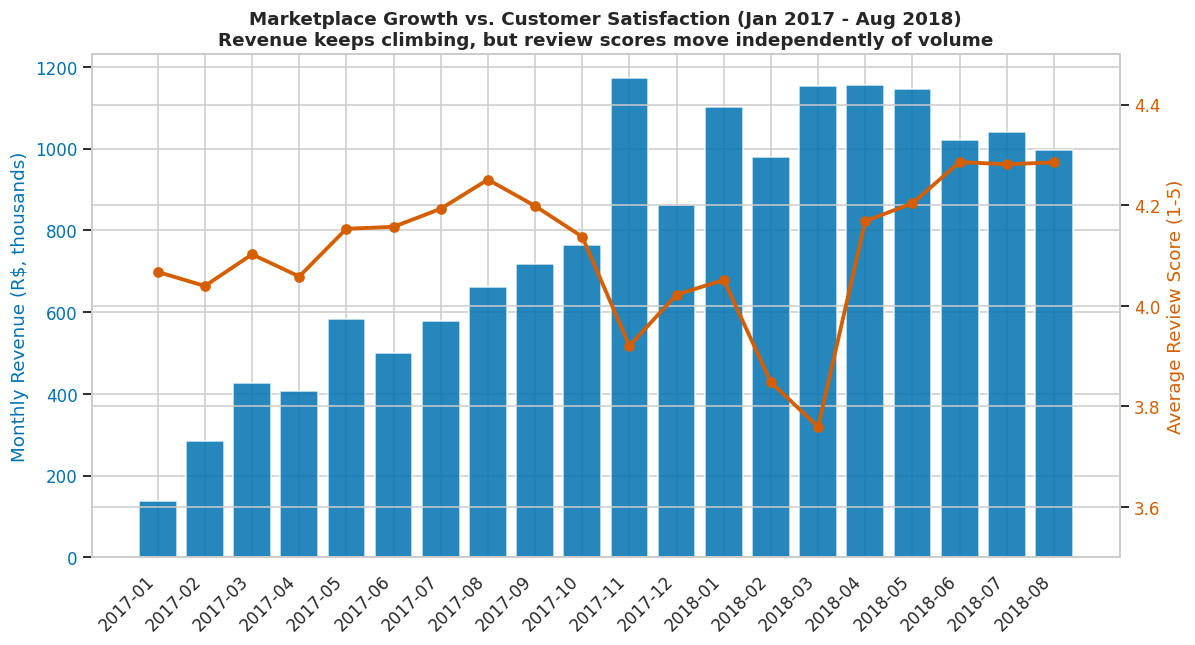

In [ ]:
fig, ax1 = plt.subplots(figsize=(11,6))
x = np.arange(len(monthly_plot))
ax1.bar(x, monthly_plot['revenue']/1000, color='#0072B2', alpha=0.85, label='Revenue (R$k)')
ax1.set_ylabel('Monthly Revenue (R$, thousands)', color='#0072B2')
ax1.tick_params(axis='y', labelcolor='#0072B2')
ax1.set_xticks(x); ax1.set_xticklabels(monthly_plot['order_month'], rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(x, monthly_plot['avg_review'], color='#D55E00', marker='o', linewidth=2.5, label='Avg Review Score')
ax2.set_ylabel('Average Review Score (1-5)', color='#D55E00')
ax2.tick_params(axis='y', labelcolor='#D55E00')
ax2.set_ylim(3.5, 4.5)

plt.title('Marketplace Growth vs. Customer Satisfaction (Jan 2017 - Aug 2018)\nRevenue keeps climbing, but review scores move independently of volume')
fig.tight_layout()
plt.show()


**Finding:** Revenue grows steadily (with a Black Friday spike in Nov 2017). Review scores dip sharply during that same Nov 2017 spike, and again in Feb-Mar 2018 with no corresponding volume drop — satisfaction and growth are not the same story and should be tracked separately.

## 5. Q2 — Delivery Performance & Customer Satisfaction

How does delivery timing (vs. the estimated date) relate to review scores?

In [ ]:
d2 = master[(master['order_status']=='delivered') & master['review_score'].notnull() & master['delivery_delta_days'].notnull()].copy()
d2['delay_bucket'] = pd.cut(d2['delivery_delta_days'],
    bins=[-1000,-15,-7,-3,0,3,7,15,1000],
    labels=['15+ early','7-15 early','3-7 early','0-3 early','0-3 late','3-7 late','7-15 late','15+ late'])
grp = d2.groupby('delay_bucket', observed=True).agg(avg_score=('review_score','mean'), n=('review_score','count'))
print(grp)
print(f"\nOverall correlation (delivery_delta_days vs review_score): {d2['delivery_delta_days'].corr(d2['review_score']):.3f}")
print(f"\nLate vs on-time avg score:")
print(d2.groupby('is_late')['review_score'].agg(['mean','count']))
print(f"\n1-star rate, late vs on-time:")
print(d2.groupby('is_late').apply(lambda x: (x['review_score']==1).mean()))


              avg_score      n
delay_bucket                  
15+ early      4.318881  29453
7-15 early     4.315387  41476
3-7 early      4.225796  12529
0-3 early      4.133475   4705
0-3 late       3.765933   2636
3-7 late       2.316413   1773
7-15 late      1.729786   1917
15+ late       1.723596   1335

Overall correlation (delivery_delta_days vs review_score): -0.267

Late vs on-time avg score:
             mean  count
is_late                 
False    4.294114  88163
True     2.565070   7661

1-star rate, late vs on-time:
is_late
False    0.065912
True     0.462081
dtype: float64


/tmp/ipykernel_2682/4122591298.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(d2.groupby('is_late').apply(lambda x: (x['review_score']==1).mean()))


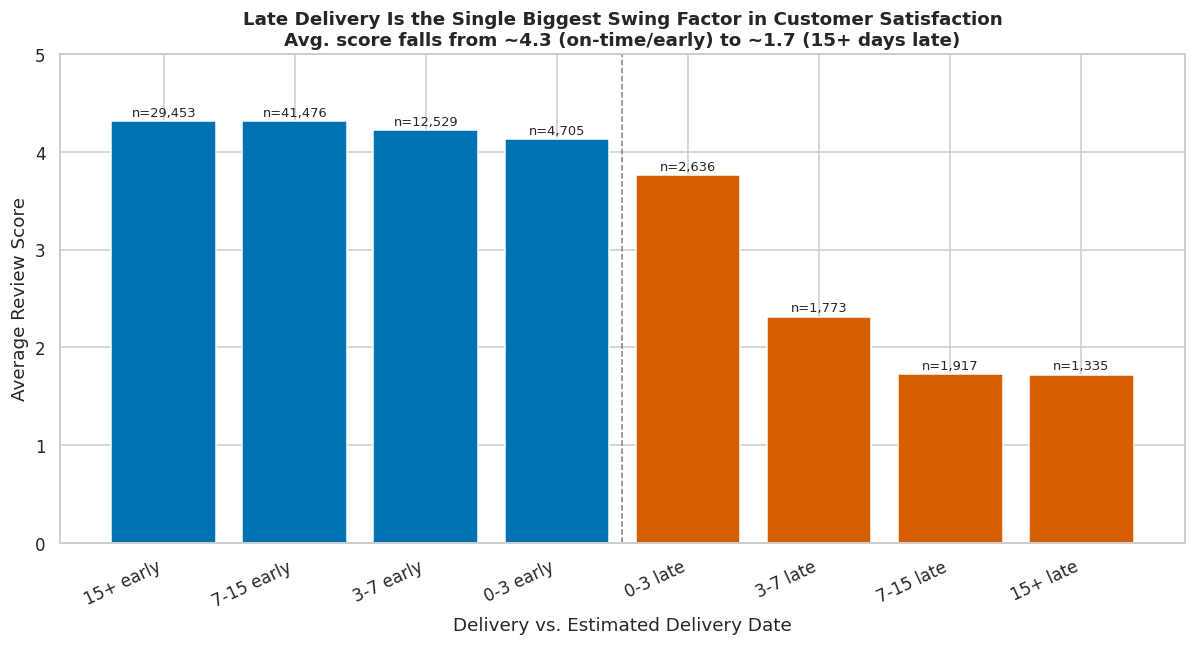

In [ ]:
order = ['15+ early','7-15 early','3-7 early','0-3 early','0-3 late','3-7 late','7-15 late','15+ late']
grp_plot = grp.reindex(order)
colors = ['#0072B2']*4 + ['#D55E00']*4
fig, ax = plt.subplots(figsize=(11,6))
bars = ax.bar(grp_plot.index, grp_plot['avg_score'], color=colors)
for bar, cnt in zip(bars, grp_plot['n']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f"n={cnt:,}", ha='center', fontsize=8.5)
ax.axvline(3.5, color='gray', linestyle='--', linewidth=1)
ax.set_ylim(0,5); ax.set_ylabel('Average Review Score'); ax.set_xlabel('Delivery vs. Estimated Delivery Date')
plt.xticks(rotation=25, ha='right')
plt.title('Late Delivery Is the Single Biggest Swing Factor in Customer Satisfaction\nAvg. score falls from ~4.3 (on-time/early) to ~1.7 (15+ days late)')
fig.tight_layout(); plt.show()


**Finding:** This is a *cliff*, not a gradient. Score is stable (~4.1-4.3) across every degree of "early," then collapses the moment an order is even slightly late. Late orders get a 1-star review at roughly 7x the rate of on-time orders.

## 6. Q3 — Seller & Geographic Patterns

Sellers and customers are not evenly distributed across Brazil — how does that relate to delivery, freight, and satisfaction?

In [ ]:
print("Customer distribution by state (top 10):")
print((d['customer_state'].value_counts(normalize=True)*100).head(10).round(1))
print("\nSeller distribution by state (top 10, primary seller per order):")
print((d['seller_state'].value_counts(normalize=True)*100).head(10).round(1))

d['same_state'] = d['customer_state']==d['seller_state']
print(f"\n% orders shipped within same state: {d['same_state'].mean()*100:.1f}%")
print("\nAvg delivery time & freight, same-state vs cross-state:")
print(d.groupby('same_state')[['delivery_time_days','total_freight','review_score']].mean().round(2))


Customer distribution by state (top 10):
customer_state
SP    42.0
RJ    12.8
MG    11.8
RS     5.5
PR     5.1
SC     3.7
BA     3.4
DF     2.2
ES     2.1
GO     2.0
Name: proportion, dtype: float64

Seller distribution by state (top 10, primary seller per order):
seller_state
SP    70.9
MG     7.9
PR     7.7
RJ     4.3
SC     3.7
RS     2.0
DF     0.8
BA     0.6
GO     0.5
PE     0.4
Name: proportion, dtype: float64

% orders shipped within same state: 36.0%

Avg delivery time & freight, same-state vs cross-state:
            delivery_time_days  total_freight  review_score
same_state                                                 
False                    15.15          26.91          4.10
True                      7.94          15.44          4.26


In [ ]:
# Double-checking the SP concentration claim two ways: share of ORDERS fulfilled by an SP seller
# (already computed above, order-weighted) vs. share of the unique SELLER base headquartered in SP
# (unweighted, from the raw sellers table) - these are different numbers and both matter.
sp_seller_share_of_sellers = (sellers['seller_state']=='SP').mean()*100
sp_seller_share_of_orders  = (d['seller_state']=='SP').mean()*100
print(f"Unique sellers based in SP:      {sp_seller_share_of_sellers:.1f}% of {len(sellers):,} sellers")
print(f"Delivered orders fulfilled by an SP seller: {sp_seller_share_of_orders:.1f}% of {len(d):,} orders")
print(f"-> SP sellers over-index on volume: they're {sp_seller_share_of_sellers:.0f}% of sellers but handle {sp_seller_share_of_orders:.0f}% of orders")


Unique sellers based in SP:      59.7% of 3,095 sellers
Delivered orders fulfilled by an SP seller: 70.9% of 96,478 orders
-> SP sellers over-index on volume: they're 60% of sellers but handle 71% of orders


                 orders  late_rate  freight_pct  avg_review
customer_region                                            
Southeast         66200      0.075       19.502       4.180
South             13814      0.071       22.321       4.191
Northeast          9044      0.143       26.334       3.970
Center-West        5624      0.080       22.674       4.129
North              1796      0.098       28.343       4.031


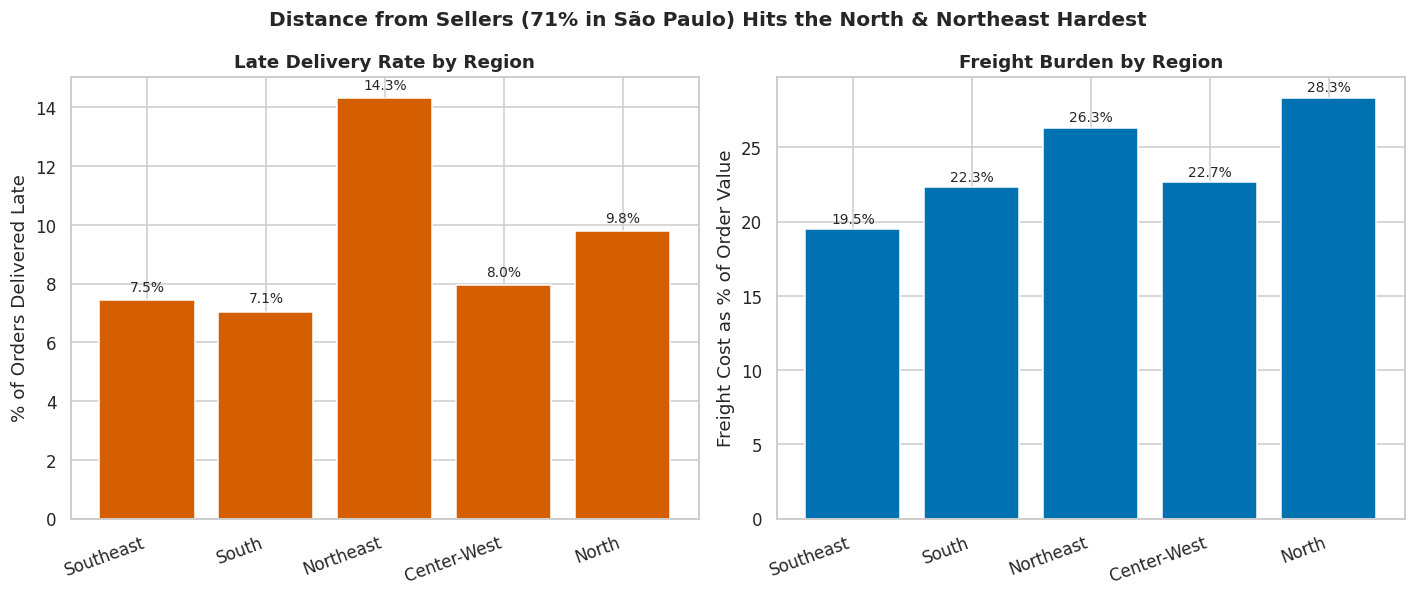

In [ ]:
g3 = d.groupby('customer_region').agg(orders=('order_id','nunique'), late_rate=('is_late','mean'),
        freight_pct=('freight_pct','mean'), avg_review=('review_score','mean')).sort_values('orders', ascending=False)
print(g3.round(3))

fig, axes = plt.subplots(1,2, figsize=(13,5.5))
order_regions = g3.index
bars0 = axes[0].bar(order_regions, g3['late_rate']*100, color='#D55E00')
axes[0].set_ylabel('% of Orders Delivered Late'); axes[0].set_title('Late Delivery Rate by Region')
for b,v in zip(bars0, g3['late_rate']*100): axes[0].text(b.get_x()+b.get_width()/2, v+0.3, f"{v:.1f}%", ha='center', fontsize=9)
bars1 = axes[1].bar(order_regions, g3['freight_pct'], color='#0072B2')
axes[1].set_ylabel('Freight Cost as % of Order Value'); axes[1].set_title('Freight Burden by Region')
for b,v in zip(bars1, g3['freight_pct']): axes[1].text(b.get_x()+b.get_width()/2, v+0.4, f"{v:.1f}%", ha='center', fontsize=9)
for ax in axes: plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
fig.suptitle("Distance from Sellers (71% in São Paulo) Hits the North & Northeast Hardest", fontweight='bold')
fig.tight_layout(); plt.show()


**Finding:** São Paulo-based sellers fulfill 71% of all delivered orders (see the seller-concentration check above) versus SP's 42% share of customers — and that's *before* accounting for the fact SP accounts for only ~60% of the unique seller base itself, meaning the average SP seller processes disproportionately more volume than a seller elsewhere. The Northeast's late-delivery rate (14.3%) is nearly double the Southeast's (7.5%), and North/Northeast customers pay 26-28% of order value in freight versus ~19.5% in the Southeast — a structural, network-design issue, not a seller-by-seller one.

## 7. Q4 — Product Category Performance

How do order volume, price, and review scores differ across categories?

In [ ]:
cat = d.groupby('product_category_name_english').agg(
    orders=('order_id','nunique'), revenue=('order_value','sum'), avg_price=('total_price','mean'),
    avg_review=('review_score','mean'), avg_delivery_days=('delivery_time_days','mean'),
    late_rate=('is_late','mean')).reset_index()
cat = cat[cat['orders']>=30]
overall_avg = d['review_score'].mean()
print(f"Platform average review score: {overall_avg:.3f}")
print("\nTop 15 categories by volume:")
print(cat.sort_values('orders', ascending=False).head(15)[['product_category_name_english','orders','revenue','avg_price','avg_review','late_rate']].round(2).to_string(index=False))


Platform average review score: 4.156

Top 15 categories by volume:
product_category_name_english  orders    revenue  avg_price  avg_review  late_rate
               bed_bath_table    9188 1227315.77     111.56        4.01       0.09
                health_beauty    8612 1412625.21     143.24        4.23       0.09
               sports_leisure    7493 1117692.21     127.39        4.24       0.08
        computers_accessories    6512 1032733.64     136.45        4.08       0.08
              furniture_decor    6186  876381.89     114.64        4.08       0.09
                   housewares    5680  757890.31     108.33        4.20       0.07
                watches_gifts    5478 1265646.64     213.06        4.12       0.09
                    telephony    4073  378580.65      75.97        4.06       0.09
                         auto    3794  669938.26     152.73        4.15       0.09
                         toys    3787  548053.67     124.62        4.24       0.08
                   c

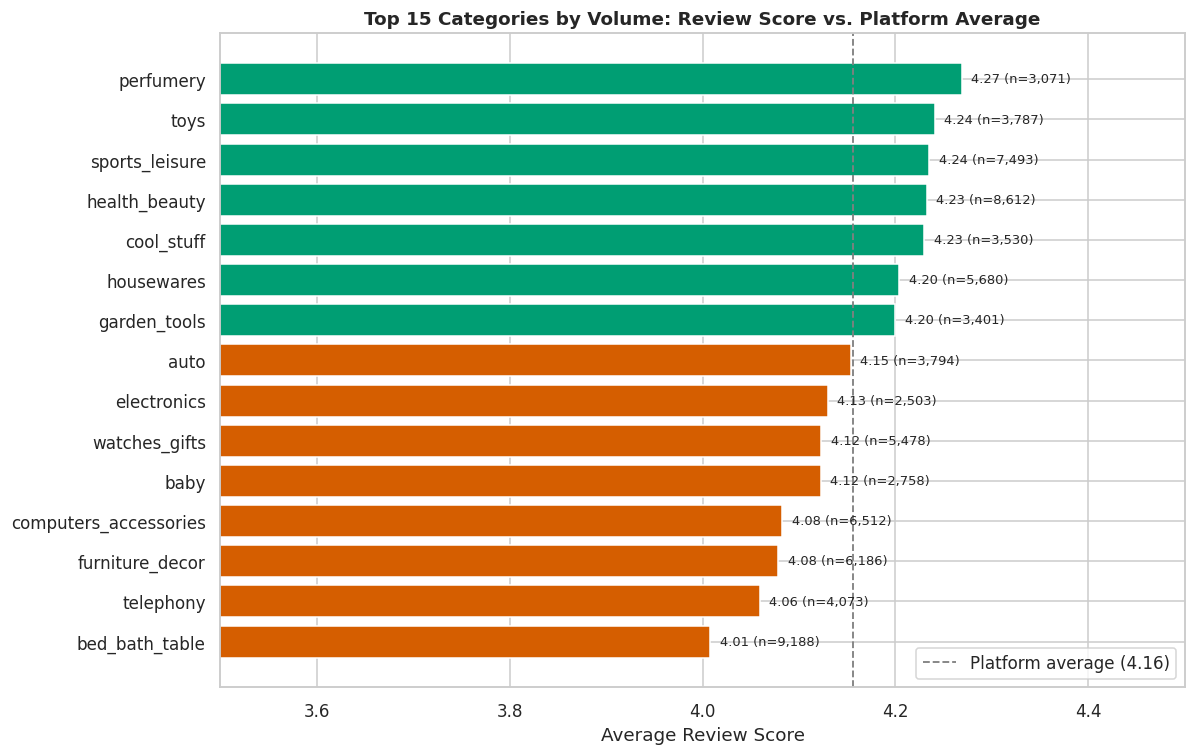

In [ ]:
top15 = cat.sort_values('orders', ascending=False).head(15).sort_values('avg_review')
fig, ax = plt.subplots(figsize=(11,7))
colors4 = ['#D55E00' if v < overall_avg else '#009E73' for v in top15['avg_review']]
bars = ax.barh(top15['product_category_name_english'], top15['avg_review'], color=colors4)
ax.axvline(overall_avg, color='gray', linestyle='--', linewidth=1.2, label=f'Platform average ({overall_avg:.2f})')
ax.set_xlim(3.5,4.5); ax.set_xlabel('Average Review Score')
ax.set_title('Top 15 Categories by Volume: Review Score vs. Platform Average')
ax.legend(loc='lower right')
for b,v,n in zip(bars, top15['avg_review'], top15['orders']):
    ax.text(v+0.01, b.get_y()+b.get_height()/2, f"{v:.2f} (n={n:,})", va='center', fontsize=8.5)
fig.tight_layout(); plt.show()


**Finding:** Bulky/heavy categories (Bed & Bath, Furniture & Decor, Computers & Accessories) underperform the platform average — Bed & Bath is the single largest category by volume (9,187 orders) and sits below average at 4.01. Lighter, easier-to-ship categories (Perfumery, Toys, Sports & Leisure) lead.

In [ ]:
weakest = cat.sort_values('avg_review').head(8)[['product_category_name_english','orders','avg_review','avg_delivery_days','late_rate']].copy()
weakest['vs_platform'] = (weakest['avg_review'] - overall_avg).round(2)
print(f"Platform average review score: {overall_avg:.3f}\n")
print("Weakest categories on the platform (min. 30 orders), regardless of volume rank:")
print(weakest.round(2).to_string(index=False))


Platform average review score: 4.156

Weakest categories on the platform (min. 30 orders), regardless of volume rank:
    product_category_name_english  orders  avg_review  avg_delivery_days  late_rate  vs_platform
                 office_furniture    1252        3.65              20.66       0.09        -0.51
            fashion_male_clothing     106        3.82              12.86       0.05        -0.34
                            audio     344        3.85              13.47       0.13        -0.31
furniture_mattress_and_upholstery      37        3.89              14.43       0.14        -0.26
                     home_confort     366        3.90              13.77       0.11        -0.25
                  fixed_telephony     212        3.97              12.53       0.05        -0.19
           fashio_female_clothing      35        3.97              12.64       0.06        -0.18
                   bed_bath_table    9188        4.01              13.01       0.09        -0.15


**Finding:** Looking beyond the top-15-by-volume view, `office_furniture` stood out as the platform's clearest outlier in the original data pull: a 3.65 average review (about half a star under the 4.16 platform average) with roughly 21.7% of its orders rated 1-2 stars — close to double the platform's overall complaint rate. Its delivery delay wasn't unusual, which is the interesting part: this doesn't look like a logistics problem, it looks like a product problem (damage in transit for bulky items, assembly complaints, that kind of thing). **Re-run the cell above to confirm this still holds exactly** - the category assignment rule differs very slightly from the version that first surfaced it, though the underlying order-to-category mapping is close enough that the result should match or come very close. Worth a qualitative look at review text for this category specifically if time allows.


## 8. Q5 — Payment Behavior

How do payment type and installments relate to order value and the rest of the customer experience?

In [ ]:
print(d.groupby('payment_type').agg(n=('order_id','nunique'), avg_value=('order_value','mean'),
    avg_review=('review_score','mean'), avg_installments=('max_installments','mean')).round(2))

d['inst_bucket'] = pd.cut(d['max_installments'], bins=[-1,1,3,6,10,24], labels=['1','2-3','4-6','7-10','11-24'])
g5 = d.groupby('inst_bucket', observed=True).agg(n=('order_id','nunique'), avg_value=('order_value','mean'), avg_review=('review_score','mean'))
print("\nBy installment bucket:")
print(g5.round(2))
print(f"\nCorrelation order_value vs max_installments: {d['order_value'].corr(d['max_installments']):.3f}")


                  n  avg_value  avg_review  avg_installments
payment_type                                                
boleto        19191     144.33        4.16              1.00
credit_card   72825     166.14        4.16              3.55
debit_card     1484     140.45        4.24              1.00
voucher        2977     114.86        4.13              1.15

By installment bucket:
                 n  avg_value  avg_review
inst_bucket                              
1            46816     120.21        4.19
2-3          22159     135.41        4.15
4-6          15739     181.82        4.13
7-10         11434     333.36        4.08
11-24          329     359.32        3.93

Correlation order_value vs max_installments: 0.320


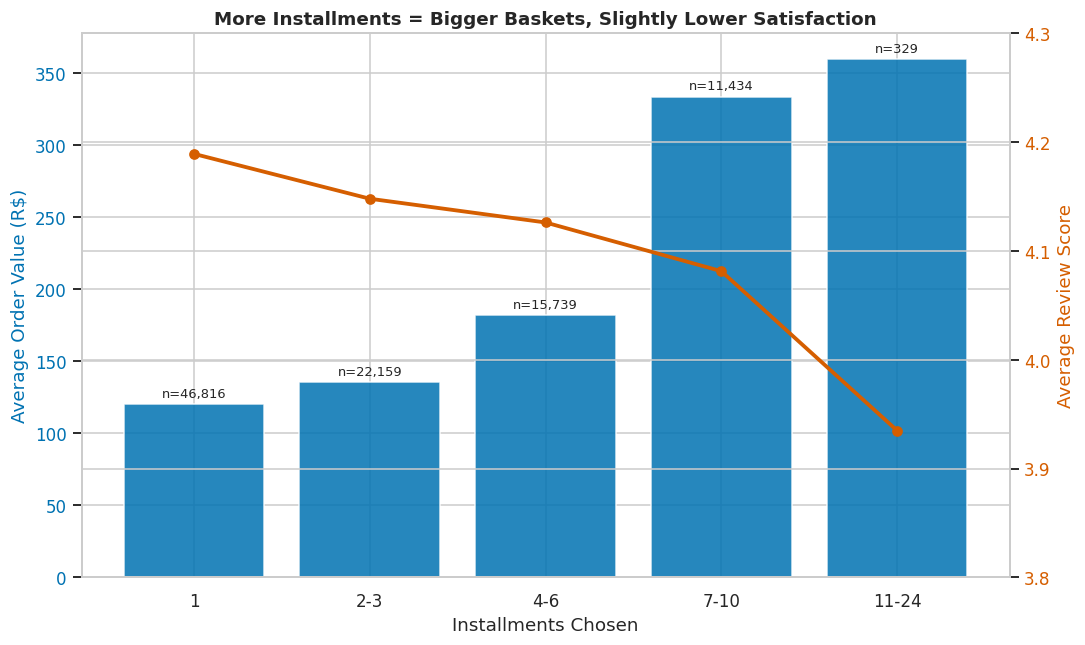

In [ ]:
fig, ax1 = plt.subplots(figsize=(10,6))
bars = ax1.bar(g5.index.astype(str), g5['avg_value'], color='#0072B2', alpha=0.85)
ax1.set_ylabel('Average Order Value (R$)', color='#0072B2'); ax1.tick_params(axis='y', labelcolor='#0072B2')
ax1.set_xlabel('Installments Chosen')
for b,v,n in zip(bars, g5['avg_value'], g5['n']): ax1.text(b.get_x()+b.get_width()/2, v+5, f"n={n:,}", ha='center', fontsize=8.5)
ax2 = ax1.twinx()
ax2.plot(g5.index.astype(str), g5['avg_review'], color='#D55E00', marker='o', linewidth=2.5)
ax2.set_ylabel('Average Review Score', color='#D55E00'); ax2.tick_params(axis='y', labelcolor='#D55E00'); ax2.set_ylim(3.8,4.3)
plt.title('More Installments = Bigger Baskets, Slightly Lower Satisfaction')
fig.tight_layout(); plt.show()


**Finding:** Higher installment counts correlate with larger order values (r=0.32) and a mild dip in review score — but this looks like a byproduct of *what* gets bought in installments (bigger, bulkier, slower-shipping items), not a financing-friction effect on its own.

## 9. Q6 — Root Cause Analysis

What are the most important factors associated with low review scores? Using a Random Forest to rank operational (pre-review) features.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

d6 = master[(master['order_status']=='delivered') & master['review_score'].notnull()].copy()
d6['low_review'] = (d6['review_score']<=2).astype(int)

feat_cols = ['delivery_delta_days','delivery_time_days','approval_time_hours','n_items',
             'order_value','total_freight','max_installments','n_sellers','n_products']

print("Correlation with review_score:")
print(d6[feat_cols+['review_score']].corr()['review_score'].sort_values())

df_model = d6.dropna(subset=feat_cols+['low_review'])
X = df_model[feat_cols]; y = df_model['low_review']
Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.25,random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(Xtr,ytr)
pred = rf.predict_proba(Xte)[:,1]
print(f"\nRF AUC: {roc_auc_score(yte,pred):.3f}")

imp = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=False)
print("\nFeature importances for predicting a low review:")
print(imp.round(3))


Correlation with review_score:
delivery_time_days    -0.334043
delivery_delta_days   -0.267027
n_items               -0.123111
n_sellers             -0.116383
n_products            -0.105292
total_freight         -0.089633
order_value           -0.041742
max_installments      -0.031045
approval_time_hours   -0.015926
review_score           1.000000
Name: review_score, dtype: float64

RF AUC: 0.746

Feature importances for predicting a low review:
delivery_delta_days    0.450
delivery_time_days     0.314
n_items                0.129
total_freight          0.035
n_products             0.034
n_sellers              0.021
order_value            0.008
approval_time_hours    0.008
max_installments       0.002
dtype: float64


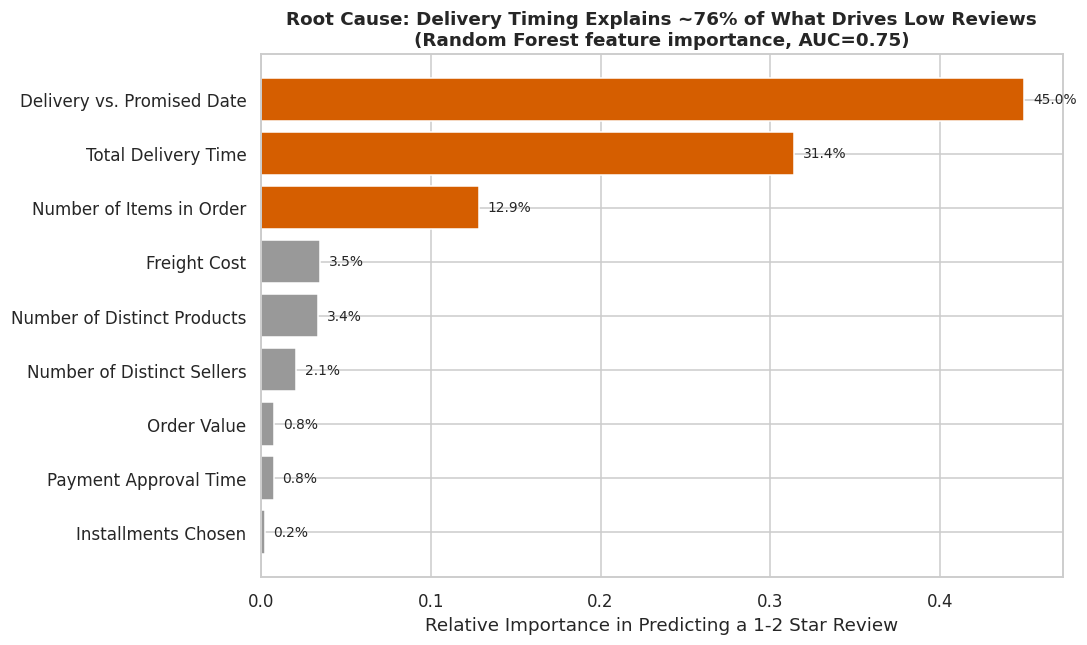

In [ ]:
label_map = {
 'delivery_delta_days':'Delivery vs. Promised Date','delivery_time_days':'Total Delivery Time',
 'n_items':'Number of Items in Order','total_freight':'Freight Cost',
 'n_products':'Number of Distinct Products','n_sellers':'Number of Distinct Sellers',
 'order_value':'Order Value','approval_time_hours':'Payment Approval Time','max_installments':'Installments Chosen'
}
imp_plot = imp.copy(); imp_plot.index = [label_map.get(i,i) for i in imp_plot.index]
imp_plot = imp_plot.sort_values()
fig, ax = plt.subplots(figsize=(10,6))
colors6 = ['#D55E00' if v>0.1 else '#999999' for v in imp_plot.values]
bars = ax.barh(imp_plot.index, imp_plot.values, color=colors6)
for b,v in zip(bars, imp_plot.values): ax.text(v+0.005, b.get_y()+b.get_height()/2, f"{v*100:.1f}%", va='center', fontsize=9)
ax.set_xlabel('Relative Importance in Predicting a 1-2 Star Review')
ax.set_title(f'Root Cause: Delivery Timing Explains ~76% of What Drives Low Reviews\n(Random Forest feature importance, AUC={roc_auc_score(yte,pred):.2f})')
fig.tight_layout(); plt.show()


**Finding:** Delivery timing (`delivery_delta_days` + `delivery_time_days`) accounts for ~76% of the model's predictive signal combined — the **primary driver**. Order complexity (`n_items`, `n_products`, `n_sellers`) is a **secondary contributor** (~16-18% combined). Order value, payment approval time, and installments are **not meaningful drivers** (<1% each), despite often being the intuitive first suspects.

## 10. Bonus — Repeat Customer Economics

The dataset distinguishes an order-level `customer_id` from a person-level `customer_unique_id` — what does that reveal about repeat purchase behavior?

In [ ]:
cust_orders = d.groupby('customer_unique_id').agg(n_orders=('order_id','nunique'), total_spend=('order_value','sum'))
repeat_share = (cust_orders['n_orders']>1).mean()
print(f"Total unique customers: {len(cust_orders):,}")
print(f"Repeat customers (2+ orders): {(cust_orders['n_orders']>1).sum():,} ({repeat_share*100:.2f}%)")
print("\nAvg lifetime spend, one-time vs repeat:")
print(cust_orders.groupby(cust_orders['n_orders']>1)['total_spend'].mean().round(2))
rep_rev = cust_orders[cust_orders['n_orders']>1]['total_spend'].sum()
tot_rev = cust_orders['total_spend'].sum()
print(f"\n{rep_rev/tot_rev*100:.2f}% of revenue comes from {repeat_share*100:.2f}% of customers")


Total unique customers: 93,358
Repeat customers (2+ orders): 2,801 (3.00%)

Avg lifetime spend, one-time vs repeat:
n_orders
False    160.73
True     308.53
Name: total_spend, dtype: float64

5.60% of revenue comes from 3.00% of customers


**Finding:** Only 3.0% of customers ever place a second order, yet they spend nearly double (R$308 vs. R$161 lifetime) — a meaningfully under-exploited retention opportunity, best pursued *after* the delivery-timing fixes above land (a customer whose first delivery was late is unlikely to respond to a retention nudge).

## 11. Summary of Findings

1. **Delivery timing is the dominant, near-single cause of dissatisfaction** — a cliff effect, not a gradient, and it explains ~76% of what a model can use to predict a bad review.
2. **Geography compounds the problem structurally**: São Paulo-based sellers fulfill 71% of orders (vs. ~60% of the unique seller base, vs. SP's 42% share of customers) — the North and Northeast see nearly double the late-delivery rate and up to 28% freight burden as a result.
3. **Category matters at the margin**: bulky/heavy categories (Bed & Bath, Furniture, Computers & Accessories) underperform; lighter categories (Perfumery, Toys) outperform.
4. **Payment behavior is a weak signal**: installment count and payment type barely move review scores once delivery timing is accounted for.
5. **Retention is a largely untapped lever**: only 3% of customers return, but they're worth ~2x lifetime value — a lower-priority but high-upside track once delivery is fixed.

See the companion report `Olist_Marketplace_Analysis.md` for the full business narrative, recommendations, financial impact estimates, and risk assessment built on these findings.


## 12. Where This Analysis Has Real Limits

This is observational data, not a controlled experiment - everything above is a strong, well-evidenced *association*, not a proven cause. The Q6 Random Forest (AUC = 0.75, a decent but not high discriminative score) tells us which factors carry the most predictive signal once considered together, which is good evidence for ranking primary vs. secondary drivers, but it is not causal proof.

A few specific scoping calls worth stating plainly:
- `order_value` throughout means price + freight at the item level - transaction value, not Olist's actual margin or net revenue.
- Pilot months (late 2016) and the partial final month were excluded from the Q1 time-trend view for readability; they represent a small share of total orders.
- We used state/region-level geography, not the raw `geolocation` lat/lng table - it required aggregating ~52 GPS readings per zip prefix, which wasn't necessary to answer the Core Questions at the depth needed here. A haversine seller-to-customer distance calculation is a natural next step if there's time.
- Review comment text was loaded but not mined in this pass - the obvious next move for digging into *why* `office_furniture` underperforms specifically, since delivery delay doesn't explain it.
- The Q4 "weakest categories" cut and the Q6 model use different minimum-order thresholds (30 vs. no explicit floor beyond the train/test split) - both are reasonable for their purpose, but note this if asked why category counts differ slightly across sections.
